In [1]:
#unzip the digits folder into the data directory
!unzip digits.zip -d data

Archive:  digits.zip
   creating: data/test
   creating: data/train
   creating: data/test/0
   creating: data/test/1
   creating: data/test/2
   creating: data/test/3
   creating: data/test/4
   creating: data/test/5
   creating: data/test/6
   creating: data/test/7
   creating: data/test/8
   creating: data/test/9
  inflating: data/test/1/One_full (1379).jpg  
  inflating: data/test/1/One_full (1041).jpg  
  inflating: data/test/1/One_full (622).jpg  
  inflating: data/test/1/One_full (1303).jpg  
  inflating: data/test/1/One_full (323).jpg  
  inflating: data/test/1/One_full (342).jpg  
  inflating: data/test/1/One_full (2112).jpg  
  inflating: data/test/1/One_full (893).jpg  
  inflating: data/test/1/One_full (876).jpg  
  inflating: data/test/1/One_full (394).jpg  
  inflating: data/test/1/One_full (1414).jpg  
  inflating: data/test/1/One_full (1348).jpg  
  inflating: data/test/1/One_full (711).jpg  
  inflating: data/test/1/One_full (1449).jpg  
  inflating: data/test/1/One_fu

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np

In [3]:
def plot_sample_images(base_path, images_per_class=2):
    # Get the list of subfolders (class names)
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    classes.sort() # Ensure alphabetical order

    num_classes = len(classes)

    # Create a grid: Rows = Classes, Cols = images_per_class
    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(images_per_class * 3, num_classes * 3))

    # If there is only one class, wrap axes in a list to keep the loop working
    if num_classes == 1:
        axes = [axes]

    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_path, class_name)
        # Get all image files in this subfolder
        all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Pick random samples
        sample_images = random.sample(all_images, min(images_per_class, len(all_images)))

        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            # Select the correct subplot
            ax = axes[i][j] if num_classes > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img_name}", fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

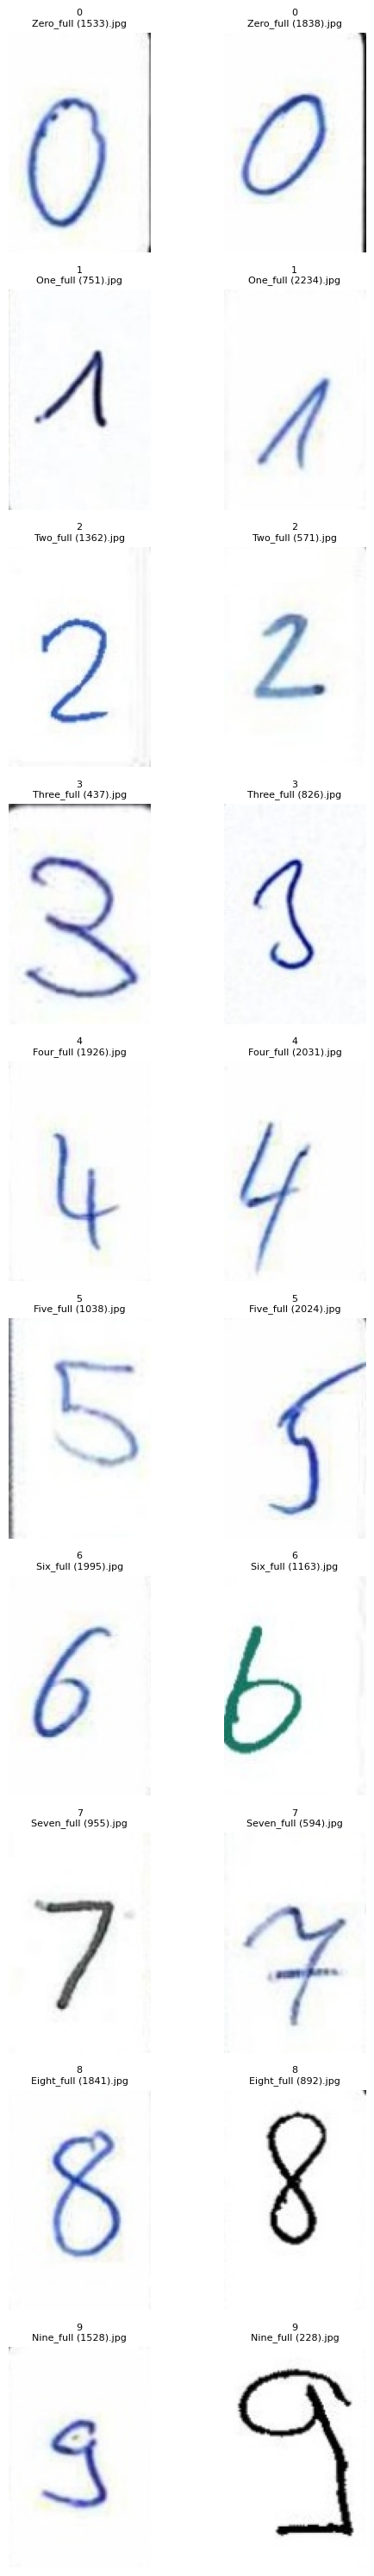

In [4]:
train_path = 'data/digits/train'

plot_sample_images(train_path, images_per_class=2)

/var/folders/gl/tjkz5rss25z3v_6dz_r7641c0000gn/T/ipykernel_10465/1128025907.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts.values, palette='viridis')


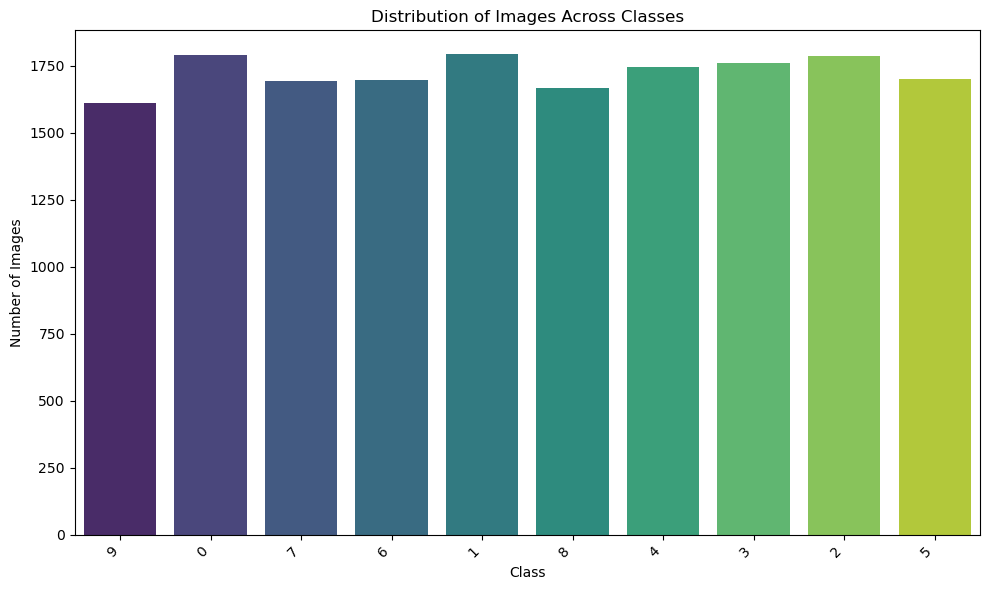

In [5]:
# Plot a histogram to assess data distribution across classes

train_dir = 'data/digits/train'

# Get a list of all class directories
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Count the number of images in each class
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
    class_counts[class_name] = num_images

# Convert to a pandas Series for easier plotting
import pandas as pd
df_counts = pd.Series(class_counts)

# Plotting the histogram (bar chart)
plt.figure(figsize=(10, 6))
sns.barplot(x=df_counts.index, y=df_counts.values, palette='viridis')
plt.title('Distribution of Images Across Classes')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import torchvision.transforms as T

training_transforms = T.Compose([
    T.Resize((32, 32)),
    T.RandomRotation(10),  # Rotate by a random angle between -10 and 10 degrees
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5])
])

test_transforms = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5])  
])

In [7]:
import torch
import torchvision.datasets as datasets

test_dir = 'data/digits/test'

train_dataset = datasets.ImageFolder(root=train_path, transform=training_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

Number of training samples: 17238
Number of testing samples: 4317


In [8]:
print(train_dataset[0][0].shape)

print(test_dataset[0][0].shape)

torch.Size([3, 32, 32])
torch.Size([3, 32, 32])


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [10]:
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")

Number of classes: 10


In [11]:
import torch.nn as nn
import torch.nn.functional as F

class DigitsMLP(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(DigitsMLP, self).__init__()
        self.input_size = 3 * 32 * 32
        self.fc1 = nn.Linear(self.input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.view(-1, self.input_size)  # Flatten the input
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print(f"MLP defined with {num_classes} output classes")
        

MLP defined with 10 output classes


In [12]:
class DigitsCNN(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(DigitsCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 4 * 4)  # Flatten the output
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x    

print(f"CNN defined with {num_classes} output classes")

CNN defined with 10 output classes


In [13]:
from sklearn.metrics import confusion_matrix, classification_report


model_mlp = DigitsMLP(num_classes=num_classes)
model_cnn = DigitsCNN(num_classes=num_classes)

criterion = nn.CrossEntropyLoss()
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=0.001)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model_mlp.to(device)
model_cnn.to(device)

num_epochs = 10


In [14]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        model.eval()
        test_running_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = test_running_loss / len(test_loader.dataset)
        test_acc = 100 * correct_test / total_test

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
                f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    return history

In [15]:
history_mlp = train_model(model_mlp, train_loader, test_loader, criterion, optimizer_mlp, num_epochs, device)

Epoch [1/10] - Train Loss: 2.1340, Train Acc: 22.42% - Test Loss: 1.8606, Test Acc: 35.97%
Epoch [2/10] - Train Loss: 1.8143, Train Acc: 36.63% - Test Loss: 1.6663, Test Acc: 45.15%
Epoch [3/10] - Train Loss: 1.6572, Train Acc: 42.84% - Test Loss: 1.5718, Test Acc: 46.24%
Epoch [4/10] - Train Loss: 1.5705, Train Acc: 45.88% - Test Loss: 1.4949, Test Acc: 48.92%
Epoch [5/10] - Train Loss: 1.5048, Train Acc: 48.79% - Test Loss: 1.5212, Test Acc: 46.68%
Epoch [6/10] - Train Loss: 1.4829, Train Acc: 48.99% - Test Loss: 1.5061, Test Acc: 47.67%
Epoch [7/10] - Train Loss: 1.4276, Train Acc: 51.20% - Test Loss: 1.3612, Test Acc: 54.34%
Epoch [8/10] - Train Loss: 1.3920, Train Acc: 52.58% - Test Loss: 1.3328, Test Acc: 55.15%
Epoch [9/10] - Train Loss: 1.3734, Train Acc: 52.99% - Test Loss: 1.3576, Test Acc: 53.35%
Epoch [10/10] - Train Loss: 1.3470, Train Acc: 53.55% - Test Loss: 1.2504, Test Acc: 58.86%


In [16]:
history_cnn = train_model(model_cnn, train_loader, test_loader, criterion, optimizer_cnn, num_epochs, device)

Epoch [1/10] - Train Loss: 0.8363, Train Acc: 71.05% - Test Loss: 0.2326, Test Acc: 92.93%
Epoch [2/10] - Train Loss: 0.1893, Train Acc: 94.03% - Test Loss: 0.1355, Test Acc: 95.67%
Epoch [3/10] - Train Loss: 0.1222, Train Acc: 96.07% - Test Loss: 0.1003, Test Acc: 96.92%
Epoch [4/10] - Train Loss: 0.0888, Train Acc: 97.20% - Test Loss: 0.0988, Test Acc: 96.94%
Epoch [5/10] - Train Loss: 0.0697, Train Acc: 97.85% - Test Loss: 0.0726, Test Acc: 97.78%
Epoch [6/10] - Train Loss: 0.0650, Train Acc: 97.91% - Test Loss: 0.1051, Test Acc: 96.83%
Epoch [7/10] - Train Loss: 0.0472, Train Acc: 98.51% - Test Loss: 0.0701, Test Acc: 97.82%
Epoch [8/10] - Train Loss: 0.0455, Train Acc: 98.45% - Test Loss: 0.0900, Test Acc: 97.61%
Epoch [9/10] - Train Loss: 0.0423, Train Acc: 98.61% - Test Loss: 0.0669, Test Acc: 97.98%
Epoch [10/10] - Train Loss: 0.0402, Train Acc: 98.61% - Test Loss: 0.0750, Test Acc: 97.89%


In [17]:
def plot_confusion_matrix(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

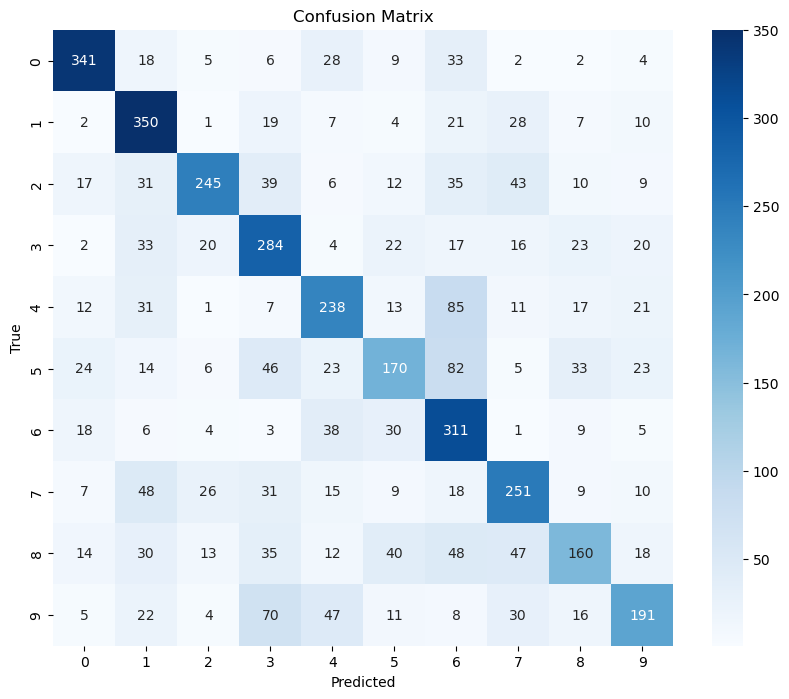

In [18]:
plot_confusion_matrix(model_mlp, test_loader, device, train_dataset.classes)

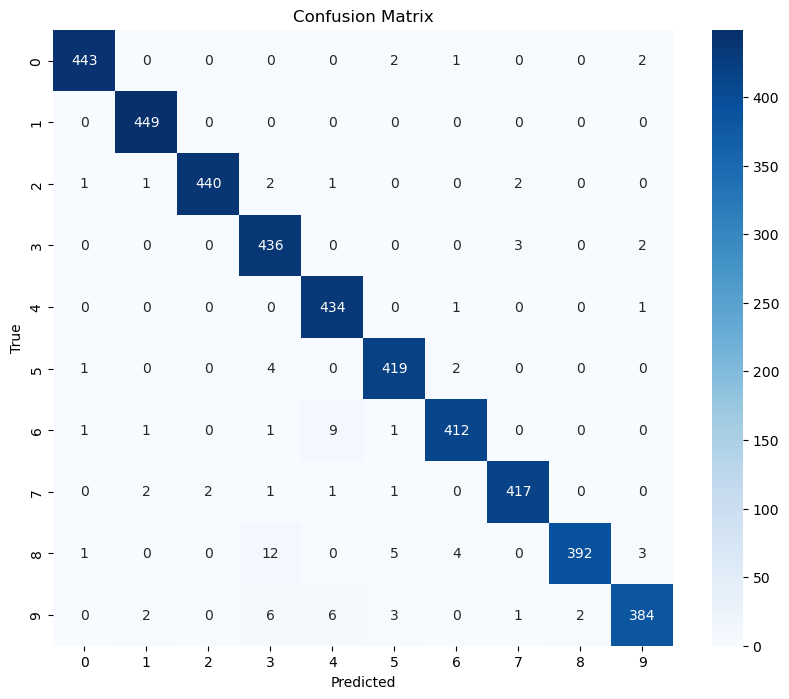

In [19]:
plot_confusion_matrix(model_cnn, test_loader, device, train_dataset.classes)

In [25]:
class DropoutDigitsCNN(nn.Module):
    def __init__(self, num_classes=num_classes, dropout_rate=0.5):
        super(DropoutDigitsCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout_rate)  # Dropout layer with specified dropout rate
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 4 * 4)  # Flatten the output
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc2(x)
        return x

print(f"CNN with Dropout defined with {num_classes} output classes and dropout rate of 0.5.")

CNN with Dropout defined with 10 output classes and dropout rate of 0.5.


In [27]:
model_cnn_dropout = DropoutDigitsCNN(num_classes=num_classes, dropout_rate=0.5)
model_cnn_dropout.to(device)
cnn_dropout_optimizer = torch.optim.Adam(model_cnn_dropout.parameters(), lr=0.001)

history_cnn_dropout = train_model(model_cnn_dropout, train_loader, test_loader, criterion, cnn_dropout_optimizer, num_epochs, device)

Epoch [1/10] - Train Loss: 1.0715, Train Acc: 63.49% - Test Loss: 0.2985, Test Acc: 91.41%
Epoch [2/10] - Train Loss: 0.3427, Train Acc: 89.19% - Test Loss: 0.1656, Test Acc: 94.90%
Epoch [3/10] - Train Loss: 0.2316, Train Acc: 92.86% - Test Loss: 0.1170, Test Acc: 96.43%
Epoch [4/10] - Train Loss: 0.1726, Train Acc: 94.66% - Test Loss: 0.0998, Test Acc: 96.73%
Epoch [5/10] - Train Loss: 0.1482, Train Acc: 95.48% - Test Loss: 0.0845, Test Acc: 97.22%
Epoch [6/10] - Train Loss: 0.1225, Train Acc: 95.97% - Test Loss: 0.0986, Test Acc: 97.10%
Epoch [7/10] - Train Loss: 0.1140, Train Acc: 96.39% - Test Loss: 0.0829, Test Acc: 97.68%
Epoch [8/10] - Train Loss: 0.1051, Train Acc: 96.79% - Test Loss: 0.0761, Test Acc: 97.89%
Epoch [9/10] - Train Loss: 0.0889, Train Acc: 97.06% - Test Loss: 0.0806, Test Acc: 97.78%
Epoch [10/10] - Train Loss: 0.0855, Train Acc: 97.27% - Test Loss: 0.0833, Test Acc: 97.61%


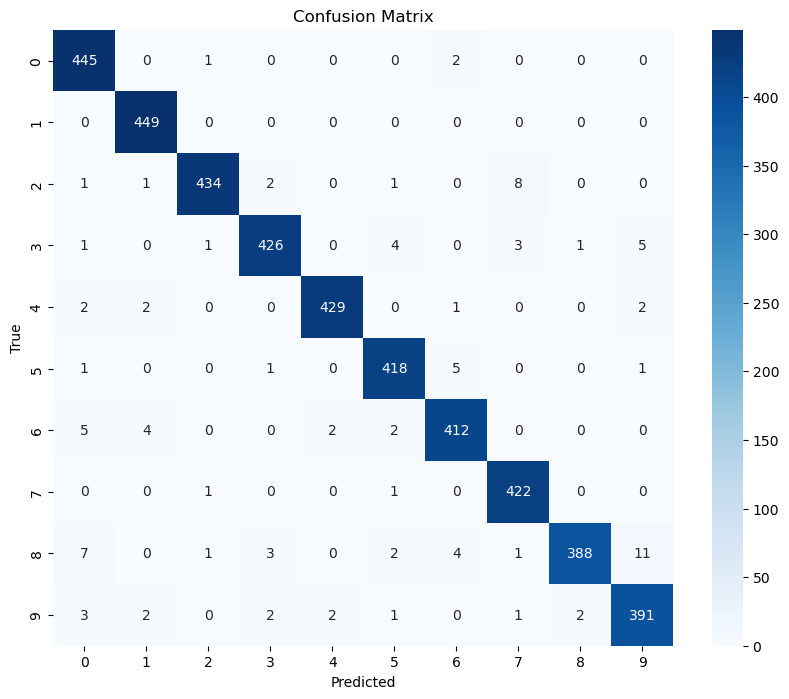

In [28]:
plot_confusion_matrix(model_cnn_dropout, test_loader, device, train_dataset.classes)